In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import c5g7
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = c5g7()

In [3]:
# Create quarter circle NURBS surface
radius = 0.54 # cm
pitch = 1.26 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))
fuel1 = cad.ruled(l0, c1)
fuel2 = cad.ruled(l0, c2)

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))
mod1 = cad.ruled(c1, l1)
mod2 = cad.ruled(c2, l2)

# NURBS surfaces
patches = {}
patches[fuel1] = "UO2"
patches[fuel2] = "UO2"
patches[mod1] = "Water"
patches[mod2] = "Water"

#set fixed sources
fixed_sources = [0,1]
strength = 1

# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 6, 2)

# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

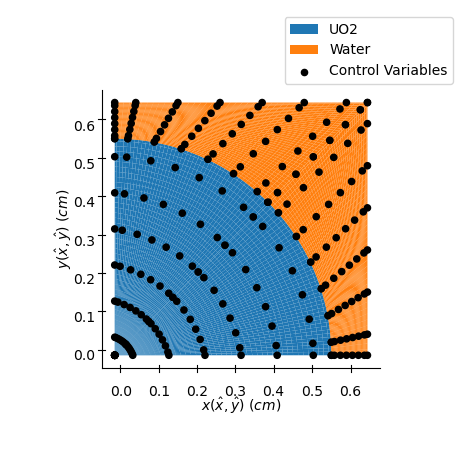

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.legend()
plt.tight_layout()
plt.savefig("./figs/pincell.png", dpi=300)
plt.show()

In [5]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    source_strength=0,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info.csv")

Assemble system in COOrdinate format


TypeError: MatrixAssembler.__init__() got an unexpected keyword argument 'source_strength'

In [ ]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 100,
        "threshold": 1e-10,
        "resets": 10,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.61432497, Angular Flux L2-Error = 2.11655865, Elapsed Time = 67.95
-- (1): k = 1.01439524, Angular Flux L2-Error = 0.32050103, Elapsed Time = 135.891
-- (2): k = 1.22383094, Angular Flux L2-Error = 0.07661425, Elapsed Time = 204.076
-- (3): k = 1.29481696, Angular Flux L2-Error = 0.0214867, Elapsed Time = 271.636
-- (4): k = 1.31653692, Angular Flux L2-Error = 0.00628622, Elapsed Time = 339.413
-- (5): k = 1.32287323, Angular Flux L2-Error = 0.00200086, Elapsed Time = 406.581
-- (6): k = 1.32468241, Angular Flux L2-Error = 0.00082915, Elapsed Time = 473.831
-- (7): k = 1.32519092, Angular Flux L2-Error = 0.00047978, Elapsed Time = 541.064
-- (8): k = 1.3253311, Angular Flux L2-Error = 0.0003264, Elapsed Time = 608.31
-- (9): k = 1.32537038, Angular Flux L2-Error = 0.00023604, Elapsed Time = 675.61
-- (10): k = 1.32538222, Angular Flux L2-Error = 0.00017689, Elapsed Time = 742.768
-- (11): k = 1.32538626, Angular Flux L2-Error = 0.00013482, Elapsed

In [ ]:
# Get OpenMC solution
k_mc = [1.325593, 0.000032]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: -20.326483494059744 +/- 3.2e-05 pcm


<Figure size 640x480 with 0 Axes>

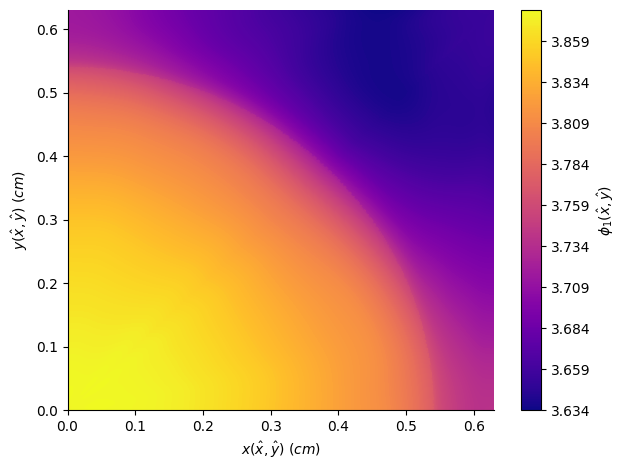

<Figure size 640x480 with 0 Axes>

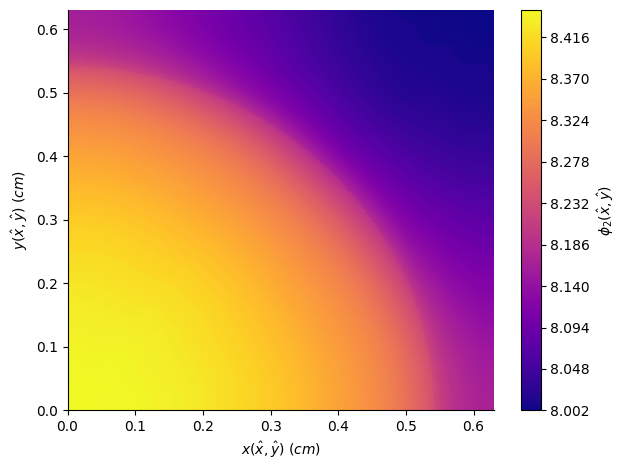

<Figure size 640x480 with 0 Axes>

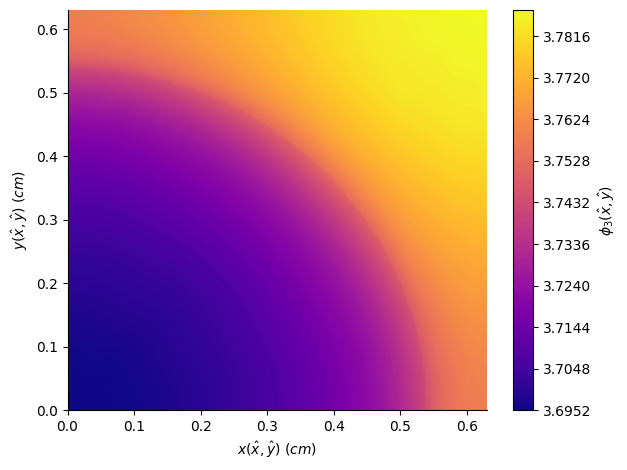

<Figure size 640x480 with 0 Axes>

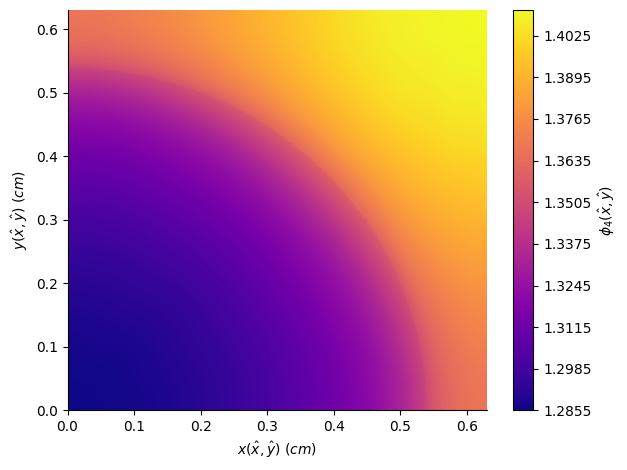

<Figure size 640x480 with 0 Axes>

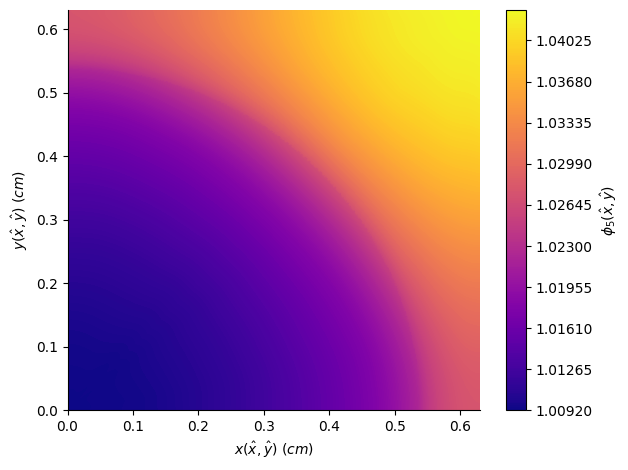

<Figure size 640x480 with 0 Axes>

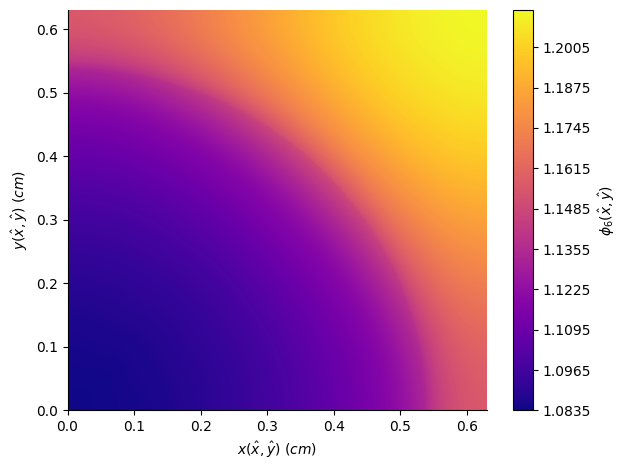

<Figure size 640x480 with 0 Axes>

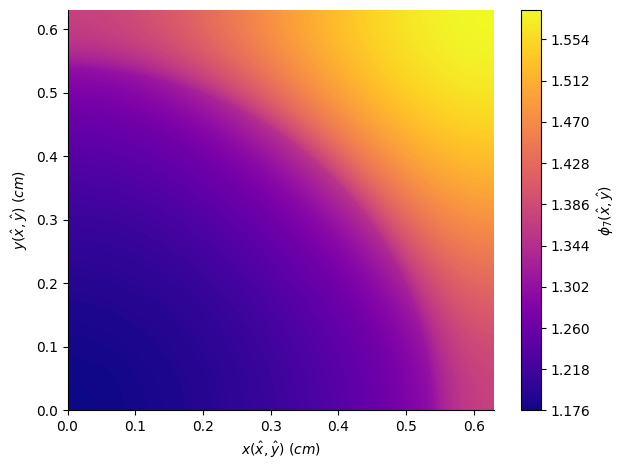

Scalar flux Relative L2-error (g = 1): 0.0047363071397367
Scalar flux Relative L2-error (g = 2): 0.0005513131390834281
Scalar flux Relative L2-error (g = 3): 0.0005647015634575882
Scalar flux Relative L2-error (g = 4): 0.0006412591174980001
Scalar flux Relative L2-error (g = 5): 0.0006776590815825124
Scalar flux Relative L2-error (g = 6): 0.0006452291185320066
Scalar flux Relative L2-error (g = 7): 0.0006588630468357189
Total scalar flux Relative L2-error: 0.0018419079468753549


In [ ]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)